<!-- @format -->

# Adult Income Prediction – Deep Learning Pipeline

Xây dựng pipeline Deep Learning hoàn chỉnh cho bài toán phân loại thu nhập trên tập dữ liệu Adult Census.

**Pipeline gồm các bước:**

1. Load dữ liệu
2. Tiền xử lý với OHE
3. MLP cơ bản
4. Optuna Hyperparameter Tuning cho MLP
5. Đánh giá & so sánh tổng hợp


<!-- @format -->

## 4.1. Import & Setup


In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import numpy as np
import pandas as pd
import torch

import modules.deep_learning as dl
import modules.tuning_mlp as ot

# Kiểm tra GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cpu


In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


<!-- @format -->

## 4.2. Load dữ liệu


In [11]:
url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = pd.read_csv(url)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


<!-- @format -->

## 4.4. Tiền xử lý chính thức

Notebook này dùng **2 nhánh preprocessing tách biệt**:

1. **MLP branch**: `StandardScaler + OneHotEncoder` cho biến phân loại.
2. **TabNet branch**: categorical được encode dạng **integer** để TabNet dùng embedding nội bộ (`cat_idxs`, `cat_dims`).

Thêm feature engineering theo yêu cầu:

- Quantile binning cho `age` và `hours-per-week`
- Loại cột dư thừa: `education`, `fnlwgt`
- Class imbalance sẽ được xử lý trong từng mô hình


In [12]:
importlib.reload(dl)

# Preprocessing cho MLP (giữ OHE).
prep = dl.preprocess_for_dl(
    df,
    target_col='income',
    cols_to_drop=['education', 'fnlwgt'],
    use_binning=True,
    n_bins=4,
    rare_threshold=0.01,
    drop_original_numeric_for_bins=True,
    random_state=42,
    test_size=0.2,
    val_size=0.2,
    cat_impute_strategy='most_frequent',
)

# Preprocessing dành riêng cho TabNet (categorical -> integer encoding + cat metadata).
prep_tabnet = dl.preprocess_for_tabnet(
    df,
    target_col='income',
    cols_to_drop=['education', 'fnlwgt'],
    use_binning=True,
    n_bins=4,
    rare_threshold=0.01,
    drop_original_numeric_for_bins=True,
    random_state=42,
    test_size=0.2,
    val_size=0.2,
    cat_impute_strategy='most_frequent',
    num_impute_strategy='median',
)

Numerical features (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (7): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Encoding mode: OHE thuần

Train: 31258  |  Val: 7815  |  Test: 9769
Rare category grouping (threshold=0.01):
  workclass: 2 rare → 'Other'  (kept 7 categories)
  marital-status: 1 rare → 'Other'  (kept 7 categories)
  occupation: 2 rare → 'Other'  (kept 13 categories)
  race: 2 rare → 'Other'  (kept 4 categories)
  native-country: 39 rare → 'Other'  (kept 3 categories)
  Total rare categories grouped: 46
Binning enabled for: ['age', 'hours-per-week']
Input dimension: 52
Target distribution (train): [23779  7479]
Rare category grouping (threshold=0.01):
  workclass: 2 rare → 'Other'  (kept 7 categories)
  marital-status: 1 rare → 'Other'  (kept 7 categories)
  occupation: 2 rare → 'Other'  (kept 13 categories)
  race: 2 rare → 'Other'  (kept 4 categories)
  native-c

In [13]:
print('[MLP] X_train shape:', prep['X_train'].shape, '| dtype:', prep['X_train'].dtype)
print('[MLP] X_val shape  :', prep['X_val'].shape)
print('[MLP] X_test shape :', prep['X_test'].shape)
print(f"[MLP] Input dimension: {prep['input_dim']}")
print('[MLP] y_train distribution:', np.bincount(prep['y_train']))
print()
print('[TabNet] X_train shape:', prep_tabnet['X_train'].shape, '| dtype:', prep_tabnet['X_train'].dtype)
print('[TabNet] X_val shape  :', prep_tabnet['X_val'].shape)
print('[TabNet] X_test shape :', prep_tabnet['X_test'].shape)
print(f"[TabNet] Input dimension: {prep_tabnet['input_dim']}")
print('[TabNet] cat_idxs:', prep_tabnet['cat_idxs'])
print('[TabNet] cat_dims:', prep_tabnet['cat_dims'])
print('[TabNet] class_weights:', prep_tabnet['class_weights'])

[MLP] X_train shape: (31258, 52) | dtype: float32
[MLP] X_val shape  : (7815, 52)
[MLP] X_test shape : (9769, 52)
[MLP] Input dimension: 52
[MLP] y_train distribution: [23779  7479]

[TabNet] X_train shape: (31258, 12) | dtype: float32
[TabNet] X_val shape  : (7815, 12)
[TabNet] X_test shape : (9769, 12)
[TabNet] Input dimension: 12
[TabNet] cat_idxs: [3, 4, 5, 6, 7, 8, 9, 10, 11]
[TabNet] cat_dims: [8, 8, 14, 7, 5, 3, 4, 5, 4]
[TabNet] class_weights: {0: 0.6572606080995836, 1: 2.089717876721487}


<!-- @format -->

## 4.6. MLP cơ bản

Mô hình MLP (Multi-Layer Perceptron) gồm:

- 2 hidden layers [128, 64] với **BatchNorm → ReLU → Dropout**
- Output layer: 1 unit (binary classification – BCEWithLogitsLoss)
- **Weighted loss** để xử lý mất cân bằng lớp
- **Adam** optimizer + **ReduceLROnPlateau** scheduler
- **Early Stopping** patience=10


In [14]:
train_loader, val_loader, test_loader = dl.create_dataloaders(prep, batch_size=256)

model_basic = dl.MLP(
    input_dim=prep['input_dim'],
    hidden_dims=[128, 64],
    dropout=0.2,
)
print(model_basic)
print(f"\nTotal parameters: {sum(p.numel() for p in model_basic.parameters()):,}")

history_basic = dl.train_model(
    model_basic,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-4,
    weight_decay=1e-3,
    patience=10,
    device=device,
)

DataLoaders created  |  batch_size=256
  Train batches: 123  |  Val batches: 31  |  Test batches: 39
MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=52, out_features=128, bias=True)
    (bn_0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (drop_0): Dropout(p=0.2, inplace=False)
    (linear_1): Linear(in_features=128, out_features=64, bias=True)
    (bn_1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (drop_1): Dropout(p=0.2, inplace=False)
    (output): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 15,489
Balanced class weights (train): {0: 0.6572606080995836, 1: 2.089717876721487} | BCE pos_weight (w1/w0): 3.1794
Training on cpu  |  epochs=50  |  lr=0.0001  |  patience=10
----------------------------------------------------------------------
Epoch   1/50  |  train_loss=0.8643  train_acc=0.6665  |  val_loss=0.7252  val_acc=0.

<!-- @format -->

### Learning Curves – MLP cơ bản


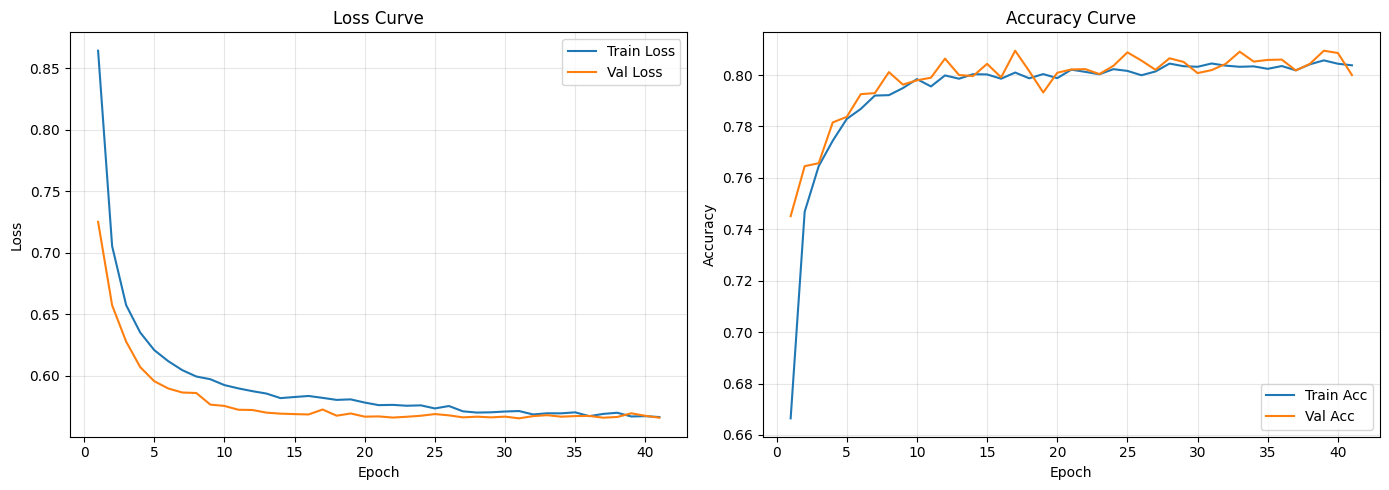

In [15]:
dl.plot_learning_curves(history_basic)

<!-- @format -->

### Đánh giá MLP cơ bản trên Test Set


=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.95      0.77      0.85      7431
        >50K       0.54      0.87      0.67      2338

    accuracy                           0.79      9769
   macro avg       0.75      0.82      0.76      9769
weighted avg       0.85      0.79      0.81      9769

Summary: {'accuracy': 0.7935, 'precision': 0.5429, 'recall': 0.8687, 'f1_score': 0.6682}


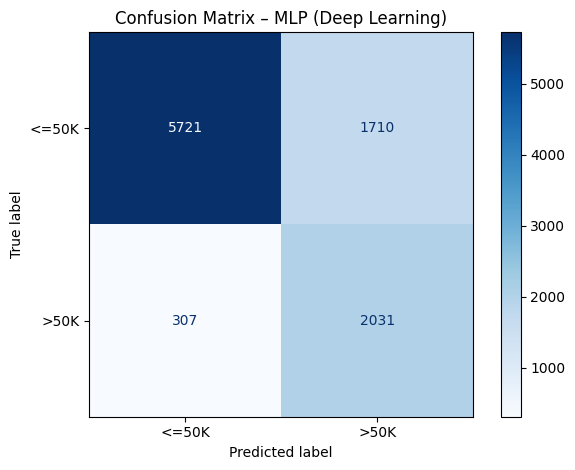

In [16]:
metrics_basic, _, _, _ = dl.evaluate_model(model_basic, test_loader, device=device)

<!-- @format -->

## 4.7. MLP với cấu hình tối ưu đã có sẵn

Phần tìm kiếm hyperparameter bằng Optuna được chạy **riêng** trước đó, không nằm trong notebook pipeline này.

Notebook chỉ sử dụng lại cấu hình MLP tốt nhất đã có để train và đánh giá trực tiếp.

**Best Params (đã có sẵn):**

- n_layers: 4
- hidden_dims: [448, 384, 320, 224]
- dropout: 0.25
- lr: 0.004570385340130139
- weight_decay: 0.009529791664976119
- batch_size: 256
- optimizer: AdamW


In [17]:
best_params_mlp = {
    'n_layers': 4,
    'hidden_dim_0': 448,
    'hidden_dim_1': 384,
    'hidden_dim_2': 320,
    'hidden_dim_3': 224,
    'dropout': 0.25,
    'lr': 0.004570385340130139,
    'weight_decay': 0.009529791664976119,
    'batch_size': 256,
    'optimizer': 'AdamW',
}

print('Using precomputed MLP best params (no Optuna run in this notebook):')
for k, v in best_params_mlp.items():
    print(f'  {k}: {v}')

Using precomputed MLP best params (no Optuna run in this notebook):
  n_layers: 4
  hidden_dim_0: 448
  hidden_dim_1: 384
  hidden_dim_2: 320
  hidden_dim_3: 224
  dropout: 0.25
  lr: 0.004570385340130139
  weight_decay: 0.009529791664976119
  batch_size: 256
  optimizer: AdamW


<!-- @format -->

### Train MLP theo cấu hình tối ưu đã có sẵn


DataLoaders created  |  batch_size=256
  Train batches: 123  |  Val batches: 31  |  Test batches: 39
Training MLP best-config on cpu | epochs=50 | patience=10
----------------------------------------------------------------------
Epoch   1/50 | train_loss=0.6177 train_acc=0.7868 | val_loss=0.5695 val_acc=0.8177 *
Epoch   2/50 | train_loss=0.5867 train_acc=0.7963 | val_loss=0.5651 val_acc=0.7978 *
Epoch   3/50 | train_loss=0.5792 train_acc=0.8003 | val_loss=0.5648 val_acc=0.8207 *
Epoch   5/50 | train_loss=0.5690 train_acc=0.8013 | val_loss=0.5765 val_acc=0.8214
Epoch   6/50 | train_loss=0.5658 train_acc=0.8033 | val_loss=0.5622 val_acc=0.8143 *
Epoch  10/50 | train_loss=0.5568 train_acc=0.8078 | val_loss=0.5679 val_acc=0.7963
Epoch  15/50 | train_loss=0.5311 train_acc=0.8073 | val_loss=0.5857 val_acc=0.8168

Early stopping at epoch 16 (best val_loss=0.5622)
=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86  

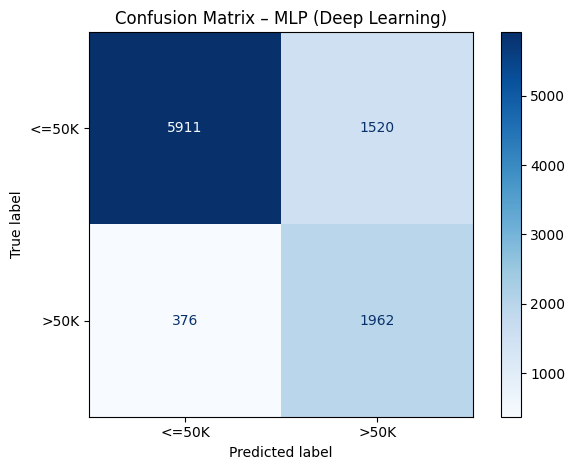

In [18]:
hidden_dims_best = [
    best_params_mlp['hidden_dim_0'],
    best_params_mlp['hidden_dim_1'],
    best_params_mlp['hidden_dim_2'],
    best_params_mlp['hidden_dim_3'],
]

train_loader_best, val_loader_best, test_loader_best = dl.create_dataloaders(
    prep, batch_size=best_params_mlp['batch_size']
 )

best_model = dl.MLP(
    input_dim=prep['input_dim'],
    hidden_dims=hidden_dims_best,
    dropout=best_params_mlp['dropout'],
 )
best_model = best_model.to(device)

# Class weights theo công thức: w_j = N / (k * n_j)
y_train_np = prep['y_train']
N = len(y_train_np)
k = len(np.unique(y_train_np))
class_counts = np.bincount(y_train_np)
w0 = N / (k * class_counts[0])
w1 = N / (k * class_counts[1])
pos_weight = torch.tensor(w1 / w0, dtype=torch.float32).to(device)

criterion_best = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_best = torch.optim.AdamW(
    best_model.parameters(),
    lr=best_params_mlp['lr'],
    weight_decay=best_params_mlp['weight_decay'],
 )
scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_best, mode='min', factor=0.5, patience=5
 )

best_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_state = None
epochs_no_improve = 0
epochs = 50
patience = 10

print(f"Training MLP best-config on {device} | epochs={epochs} | patience={patience}")
print('-' * 70)

for epoch in range(1, epochs + 1):
    train_loss, train_acc = dl.train_one_epoch(
        best_model, train_loader_best, criterion_best, optimizer_best, device
    )
    val_loss, val_acc = dl.evaluate(
        best_model, val_loader_best, criterion_best, device
    )
    scheduler_best.step(val_loss)

    best_history['train_loss'].append(train_loss)
    best_history['val_loss'].append(val_loss)
    best_history['train_acc'].append(train_acc)
    best_history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in best_model.state_dict().items()}
        epochs_no_improve = 0
        marker = ' *'
    else:
        epochs_no_improve += 1
        marker = ''

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}{marker}"
        )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
        break

if best_state is not None:
    best_model.load_state_dict(best_state)

best_model = best_model.to(device)
best_model.eval()

best_metrics, _, _, _ = dl.evaluate_model(best_model, test_loader_best, device=device)

<!-- @format -->

### Learning Curves – MLP cấu hình tối ưu đã có sẵn


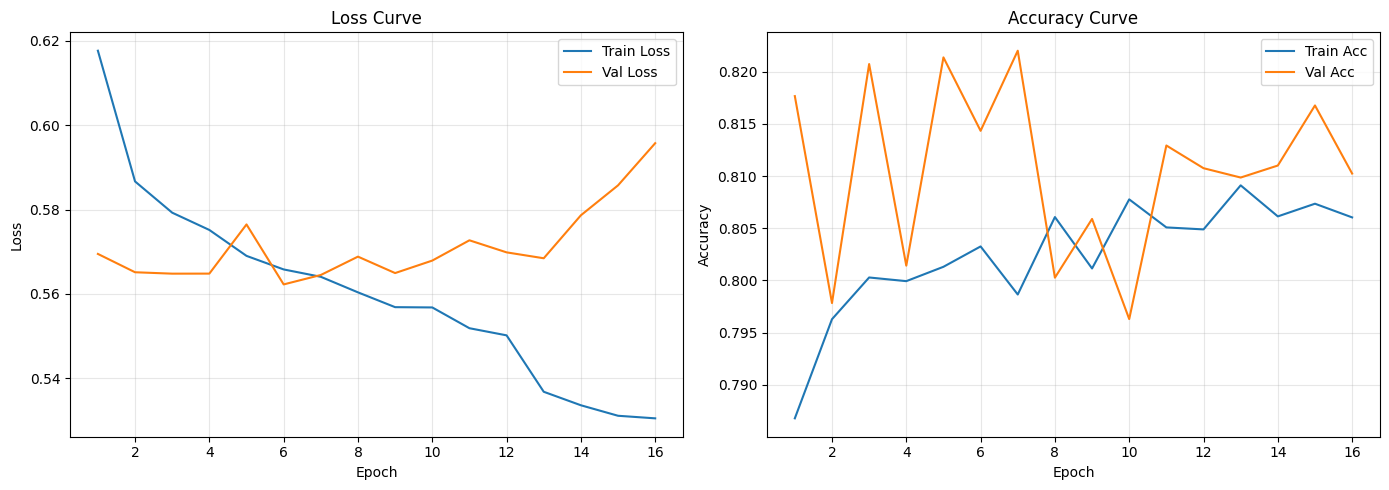

In [19]:
dl.plot_learning_curves(best_history)

<!-- @format -->

## 4.8. Tổng kết & So sánh

Bảng so sánh: **MLP cơ bản** vs **MLP cấu hình tối ưu đã có sẵn**.


In [20]:
# Bảng so sánh tổng hợp
summary_rows = [
    {
        'Model': 'MLP cơ bản [128, 64]',
        'Test Acc': metrics_basic['accuracy'],
        'Test F1': metrics_basic['f1_score'],
        'Test Precision': metrics_basic['precision'],
        'Test Recall': metrics_basic['recall'],
    },
    {
        'Model': 'MLP best-config (precomputed)',
        'Test Acc': best_metrics['accuracy'],
        'Test F1': best_metrics['f1_score'],
        'Test Precision': best_metrics['precision'],
        'Test Recall': best_metrics['recall'],
    },
]

summary_df = pd.DataFrame(summary_rows)
print('═' * 70)
print('  BẢNG SO SÁNH TỔNG HỢP')
print('═' * 70)
summary_df.style.highlight_max(
    subset=['Test Acc', 'Test F1', 'Test Precision', 'Test Recall'],
    color='lightgreen',
)

══════════════════════════════════════════════════════════════════════
  BẢNG SO SÁNH TỔNG HỢP
══════════════════════════════════════════════════════════════════════


,Model,Test Acc,Test F1,Test Precision,Test Recall
0,"MLP cơ bản [128, 64]",0.793500,0.668200,0.542900,0.868700
1,MLP best-config (precomputed),0.805900,0.674200,0.563500,0.839200


<!-- @format -->

## 4.9. TabNet (Raw Categorical + Pretraining)

TabNet trong notebook này chạy theo luồng đúng chuẩn cho dữ liệu bảng:

- Không dùng OHE cho TabNet
- Categorical encode dạng integer và truyền `cat_idxs`, `cat_dims`
- Dùng custom class weights theo công thức cân bằng lớp
- Có bước **self-supervised pretraining** trước khi fine-tune classifier

**Cài đặt (nếu chưa có):** `pip install pytorch-tabnet`

| Hyperparameter chính | Giá trị khởi tạo |
| -------------------- | ---------------- |
| n_d, n_a             | 32               |
| n_steps              | 3                |
| gamma                | 1.3              |
| lambda_sparse        | 1e-3             |
| lr                   | 2e-2             |
| max_epochs           | 100              |
| patience             | 10               |
| batch_size           | 256              |


In [21]:
# Cài pytorch-tabnet nếu chưa có
#!pip install pytorch-tabnet

# 1) Self-supervised pretraining
tabnet_pretrainer = dl.pretrain_tabnet(
    prep_tabnet,
    pretrain_epochs=60,
    n_d=32,
    n_a=32,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-3,
    lr=2e-2,
    batch_size=256,
    virtual_batch_size=128,
    pretraining_ratio=0.8,
    device=device,
 )

# 2) Fine-tune classifier từ pretrained weights
tabnet_model = dl.train_tabnet_model(
    prep_tabnet,
    n_d=32,
    n_a=32,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-3,
    lr=2e-2,
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
    custom_weights=prep_tabnet['class_weights'],
    pretrainer=tabnet_pretrainer,
    device=device,
 )

d:\Học máy\ml-project-group10\.venv\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.78798 | val_unsup_loss_numpy: 0.9898899793624878|  0:00:07s
epoch 1  | loss: 0.96399 | val_unsup_loss_numpy: 0.9273099899291992|  0:00:14s
epoch 2  | loss: 0.95049 | val_unsup_loss_numpy: 0.8522199988365173|  0:00:22s
epoch 3  | loss: 0.94619 | val_unsup_loss_numpy: 0.8497400283813477|  0:00:29s
epoch 4  | loss: 0.93928 | val_unsup_loss_numpy: 0.8466600179672241|  0:00:37s
epoch 5  | loss: 0.93655 | val_unsup_loss_numpy: 0.8469899892807007|  0:00:44s
epoch 6  | loss: 0.93649 | val_unsup_loss_numpy: 0.8336300253868103|  0:00:51s
epoch 7  | loss: 0.9295  | val_unsup_loss_numpy: 0.8186299800872803|  0:01:00s
epoch 8  | loss: 0.92748 | val_unsup_loss_numpy: 0.8121899962425232|  0:01:10s
epoch 9  | loss: 0.92757 | val_unsup_loss_numpy: 0.8014199733734131|  0:01:23s
epoch 10 | loss: 0.92906 | val_unsup_loss_numpy: 0.8247500061988831|  0:01:34s
epoch 11 | loss: 0.92735 | val_unsup_loss_numpy: 0.8080899715423584|  0:01:46s
epoch 12 | loss: 0.93184 | val_unsup_loss_numpy: 0.7

KeyboardInterrupt: 

=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.94      0.82      0.87      7431
        >50K       0.59      0.82      0.69      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.82      0.78      9769
weighted avg       0.85      0.82      0.83      9769

Summary: {'accuracy': 0.8197, 'precision': 0.5881, 'recall': 0.8234, 'f1_score': 0.6862}


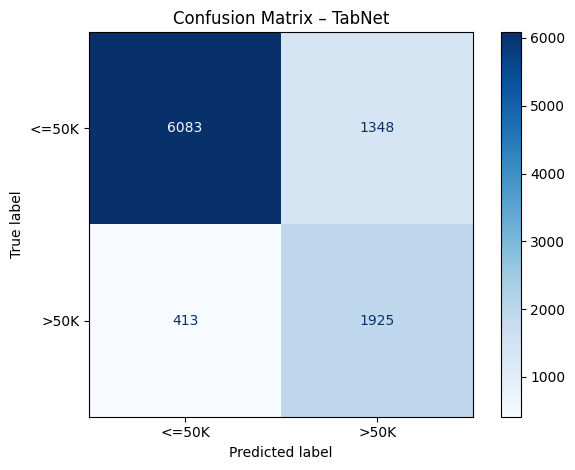

In [ ]:
metrics_tabnet, _, _, _ = dl.evaluate_tabnet(tabnet_model, prep_tabnet)

<!-- @format -->

## 4.10. Optuna Hyperparameter Tuning cho TabNet

Tìm kiếm các tham số “đặc sản” của TabNet:

- `width` (n_d = n_a)
- `n_steps`
- `gamma`
- `lambda_sparse`
- `lr`, `batch_size`, `virtual_batch_size`
- (tuỳ chọn) `pretrain_epochs`, `pretraining_ratio` nếu bật pretraining


In [ ]:
tabnet_study = ot.run_optuna_search_tabnet(
    prep_tabnet,
    n_trials=10,          # tăng lên 20-50 nếu muốn search kỹ hơn
    max_epochs=60,
    patience=8,
    device=device,
    use_pretraining=True,
 )

tabnet_best_model, tabnet_best_metrics = ot.train_best_optuna_tabnet_model(
    tabnet_study,
    prep_tabnet,
    max_epochs=100,
    patience=10,
    device=device,
    use_pretraining=True,
 )

<!-- @format -->

### So sánh nhanh sau khi thêm TabNet Pretraining

Bảng dưới đây tổng hợp kết quả giữa MLP và TabNet để theo dõi cải thiện Precision/F1 cho lớp `>50K`.


In [ ]:
compare_rows = [
    {
        'Model': 'MLP cơ bản [128, 64]',
        'Test Acc': metrics_basic['accuracy'],
        'Test F1': metrics_basic['f1_score'],
        'Test Precision': metrics_basic['precision'],
        'Test Recall': metrics_basic['recall'],
    },
    {
        'Model': 'MLP Optuna (best)',
        'Test Acc': best_metrics['accuracy'],
        'Test F1': best_metrics['f1_score'],
        'Test Precision': best_metrics['precision'],
        'Test Recall': best_metrics['recall'],
    },
    {
        'Model': 'TabNet + Pretraining (baseline)',
        'Test Acc': metrics_tabnet['accuracy'],
        'Test F1': metrics_tabnet['f1_score'],
        'Test Precision': metrics_tabnet['precision'],
        'Test Recall': metrics_tabnet['recall'],
    },
    {
        'Model': 'TabNet + Optuna (best)',
        'Test Acc': tabnet_best_metrics['accuracy'],
        'Test F1': tabnet_best_metrics['f1_score'],
        'Test Precision': tabnet_best_metrics['precision'],
        'Test Recall': tabnet_best_metrics['recall'],
    },
]

compare_df = pd.DataFrame(compare_rows)
compare_df.style.highlight_max(
    subset=['Test Acc', 'Test F1', 'Test Precision', 'Test Recall'],
    color='lightgreen',
)